In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

RANDOM_STATE = 42


In [2]:
DATA_DIR = "/mnt/user-data/uploads/"

fact = pd.read_csv(DATA_DIR + "FactSales.csv")
dim_product   = pd.read_csv(DATA_DIR + "DimProduct.csv")
dim_customer  = pd.read_csv(DATA_DIR + "DimCustomer.csv")
dim_geography = pd.read_csv(DATA_DIR + "DimGeography.csv")
dim_shipmode  = pd.read_csv(DATA_DIR + "DimShipMode.csv")
dim_priority  = pd.read_csv(DATA_DIR + "DimOrderPriority.csv")
dim_date      = pd.read_csv(DATA_DIR + "DimDate.csv")

print("FactSales:", fact.shape)
fact.head()


FactSales: (49670, 16)


,SalesRowKey,OrderID,ProductKey,CustomerKey,GeographyKey,ShipModeKey,PriorityKey,OrderDateKey,ShipDateKey,Sales,Quantity,Discount,Profit,ShippingCost,IsReturned,DeliverDays
0,2363,MX-2011-117107,2750,731,2640,4,4,20111015,20111019,703.16,2,0.0,161.72,62.398,False,4
1,831,MX-2014-135272,3021,1383,2605,4,4,20141106,20141110,32.12,2,0.0,15.72,1.296,False,4
2,1511,MX-2012-147886,404,278,2605,4,4,20120411,20120415,163.44,2,0.0,13.04,10.522,False,4
3,3399,MX-2014-107265,6837,151,2551,4,4,20140624,20140628,35.24,2,0.0,8.08,3.048,False,4
4,850,MX-2012-131254,4681,699,2551,4,4,20121204,20121208,64.88,2,0.0,21.40,5.946,False,4


In [3]:
df = (
    fact
    .merge(dim_product,   on="ProductKey",   how="left")
    .merge(dim_customer,  on="CustomerKey",  how="left")
    .merge(dim_geography, on="GeographyKey", how="left")
    .merge(dim_shipmode,  on="ShipModeKey",  how="left")
    .merge(dim_priority,  on="PriorityKey",  how="left")
    .merge(
        dim_date[["DateKey", "GregorianMonthNo", "GregorianDayOfWeekInt", "SeasonName"]],
        left_on="OrderDateKey", right_on="DateKey", how="left"
    )
)

print(df.shape)
print("Missing values after join:", df.isna().sum().sum())
df.head()


(49670, 35)
Missing values after join: 0


,SalesRowKey,OrderID,ProductKey,CustomerKey,GeographyKey,ShipModeKey,PriorityKey,OrderDateKey,ShipDateKey,Sales,...,State,Country,Region,Market,Ship Mode,Order Priority,DateKey,GregorianMonthNo,GregorianDayOfWeekInt,SeasonName
0,2363,MX-2011-117107,2750,731,2640,4,4,20111015,20111019,703.16,...,Distrito Federal,Mexico,North,LATAM,Standard Class,Medium,20111015,10,6,پاییز
1,831,MX-2014-135272,3021,1383,2605,4,4,20141106,20141110,32.12,...,Managua,Nicaragua,Central,LATAM,Standard Class,Medium,20141106,11,4,پاییز
2,1511,MX-2012-147886,404,278,2605,4,4,20120411,20120415,163.44,...,Managua,Nicaragua,Central,LATAM,Standard Class,Medium,20120411,4,3,بهار
3,3399,MX-2014-107265,6837,151,2551,4,4,20140624,20140628,35.24,...,Santiago de Cuba,Cuba,Caribbean,LATAM,Standard Class,Medium,20140624,6,2,تابستان
4,850,MX-2012-131254,4681,699,2551,4,4,20121204,20121208,64.88,...,Santiago de Cuba,Cuba,Caribbean,LATAM,Standard Class,Medium,20121204,12,2,پاییز


In [4]:
categorical_features = [
    "Category", "Sub-Category", "Segment", "Region", "Market",
    "Ship Mode", "Order Priority", "SeasonName",
]

numeric_features = [
    "Sales", "Quantity", "Discount", "ShippingCost", "DeliverDays",
    "GregorianMonthNo", "GregorianDayOfWeekInt",
]

boolean_features = ["IsReturned"]

target = "Profit"

feature_cols = categorical_features + numeric_features + boolean_features
data = df[feature_cols + [target]].copy()

# IsReturned as 0/1
data["IsReturned"] = data["IsReturned"].astype(int)

print(data.shape)
data.isna().sum()


(49670, 17)


Category                 0
Sub-Category             0
Segment                  0
Region                   0
Market                   0
Ship Mode                0
Order Priority           0
SeasonName               0
Sales                    0
Quantity                 0
Discount                 0
ShippingCost             0
DeliverDays              0
GregorianMonthNo         0
GregorianDayOfWeekInt    0
IsReturned               0
Profit                   0
dtype: int64

In [5]:
X = data[feature_cols]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (39736, 16)  Test: (9934, 16)


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="passthrough",  # keeps boolean_features
)


In [7]:
model_grid = {
    "Ridge Regression": {
        "estimator": Ridge(random_state=RANDOM_STATE),
        "param_grid": {"model__alpha": [0.1, 1.0, 10.0, 50.0]},
    },
    "Random Forest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [100],
            "model__max_depth": [5, 10],
        },
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "param_grid": {
            "model__n_estimators": [100],
            "model__max_depth": [2, 3],
        },
    },
}


In [8]:
results = []
fitted_models = {}

for name, cfg in model_grid.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", cfg["estimator"]),
    ])

    grid_search = GridSearchCV(
        pipe, cfg["param_grid"], cv=3, scoring="r2", n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    fitted_models[name] = best_model

    train_r2 = r2_score(y_train, best_model.predict(X_train))
    test_r2 = r2_score(y_test, best_model.predict(X_test))
    test_mae = mean_absolute_error(y_test, best_model.predict(X_test))

    results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "Train R2": round(train_r2, 4),
        "Test R2": round(test_r2, 4),
        "Test MAE": round(test_mae, 2),
        "Overfit Gap (Train-Test R2)": round(train_r2 - test_r2, 4),
    })

results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False).reset_index(drop=True)
results_df


,Model,Best Params,Train R2,Test R2,Test MAE,Overfit Gap (Train-Test R2)
0,Gradient Boosting,"{'model__max_depth': 3, 'model__n_estimators':...",0.8104,0.7251,37.29,0.0853
1,Random Forest,"{'model__max_depth': 10, 'model__n_estimators'...",0.8590,0.7037,34.55,0.1553
2,Ridge Regression,{'model__alpha': 50.0},0.3728,0.2330,58.35,0.1398


In [9]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_model = fitted_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Test R2:  {best_row['Test R2']}")
print(f"Train R2: {best_row['Train R2']}")
print(f"Overfit gap: {best_row['Overfit Gap (Train-Test R2)']}")
print(f"Best params: {best_row['Best Params']}")


Best model: Gradient Boosting
Test R2:  0.7251
Train R2: 0.8104
Overfit gap: 0.0853
Best params: {'model__max_depth': 3, 'model__n_estimators': 100}


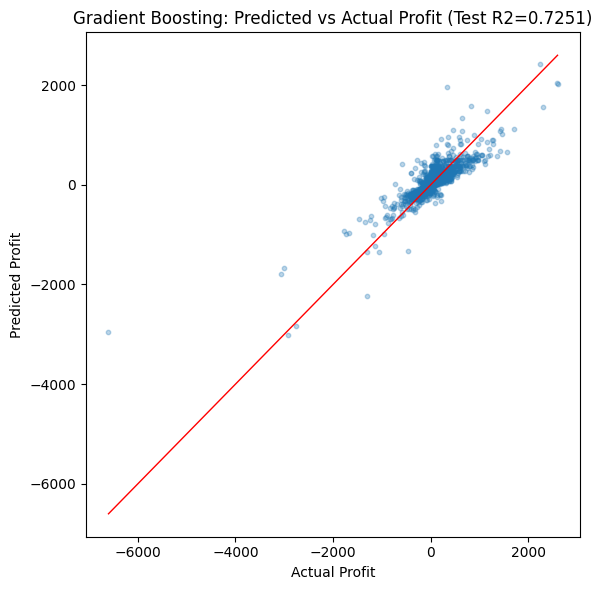

In [10]:
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color="red", linewidth=1)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title(f"{best_model_name}: Predicted vs Actual Profit (Test R2={best_row['Test R2']})")
plt.tight_layout()
plt.show()
